<a href="https://colab.research.google.com/github/ShoaibAkhtar433/ML-Task1/blob/main/Heart_Disease_Prediction_Task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#Importing Libraries

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc


In [23]:
#Loading Dataset

df = pd.read_csv('cleanned.csv')
df


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,0
4,41,Female,typical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,0
...,...,...,...,...,...,...,...,...,...,...,...
913,54,Female,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,1
914,62,Male,typical angina,130.0,139.0,False,st-t abnormality,140.0,False,0.5,0
915,55,Male,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,2
916,58,Male,asymptomatic,130.0,385.0,True,lv hypertrophy,140.0,False,0.5,0


In [6]:
# Describing Dataset

df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,918.000000,918.000000,918.000000,918.000000,918.00000,918.000000
mean,53.510893,132.141612,199.862745,137.689542,0.85512,0.995643
std,9.432617,17.924706,109.154522,25.153455,1.05845,1.142985
min,28.000000,80.000000,0.000000,60.000000,-2.60000,0.000000
25%,47.000000,120.000000,177.250000,120.000000,0.00000,0.000000
50%,54.000000,130.000000,223.000000,140.000000,0.50000,1.000000
75%,60.000000,140.000000,267.000000,155.750000,1.50000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.20000,4.000000


In [7]:
# Checking if there is a null value in dataset

df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,0


In [8]:
# Converting Target to binary form

df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
df.drop('num', axis=1, inplace=True)
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,target
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,1
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,0
4,41,Female,typical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,0
...,...,...,...,...,...,...,...,...,...,...,...
913,54,Female,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,1
914,62,Male,typical angina,130.0,139.0,False,st-t abnormality,140.0,False,0.5,0
915,55,Male,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,1
916,58,Male,asymptomatic,130.0,385.0,True,lv hypertrophy,140.0,False,0.5,0


In [9]:
# Encoding categorial features

le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['cp'] = le.fit_transform(df['cp'])
df['restecg'] = le.fit_transform(df['restecg'])
df['fbs'] = df['fbs'].astype(int)
df['exang'] = df['exang'].astype(int)
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,target
0,63,1,2,145.0,233.0,1,0,150.0,0,2.3,0
1,67,1,0,160.0,286.0,0,0,108.0,1,1.5,1
2,67,1,0,120.0,229.0,0,0,129.0,1,2.6,1
3,37,1,1,130.0,250.0,0,1,187.0,0,3.5,0
4,41,0,2,130.0,204.0,0,0,172.0,0,1.4,0
...,...,...,...,...,...,...,...,...,...,...,...
913,54,0,0,127.0,333.0,1,2,154.0,0,0.0,1
914,62,1,2,130.0,139.0,0,2,140.0,0,0.5,0
915,55,1,0,122.0,223.0,1,2,100.0,0,0.0,1
916,58,1,0,130.0,385.0,1,0,140.0,0,0.5,0


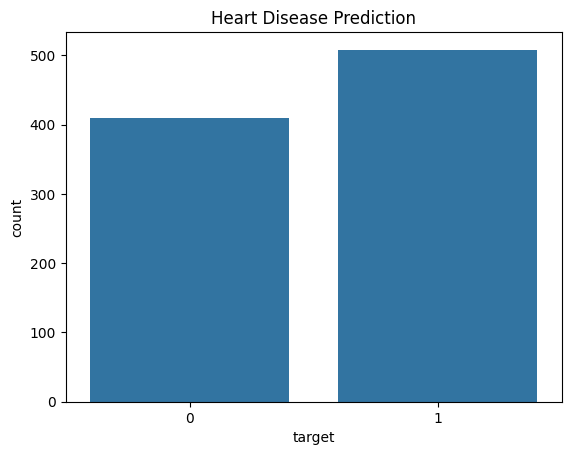

In [10]:
# Exploratory Data Analysis
# Target Distribution

sns.countplot(x= 'target', data= df)
plt.title('Heart Disease Prediction')
plt.show()

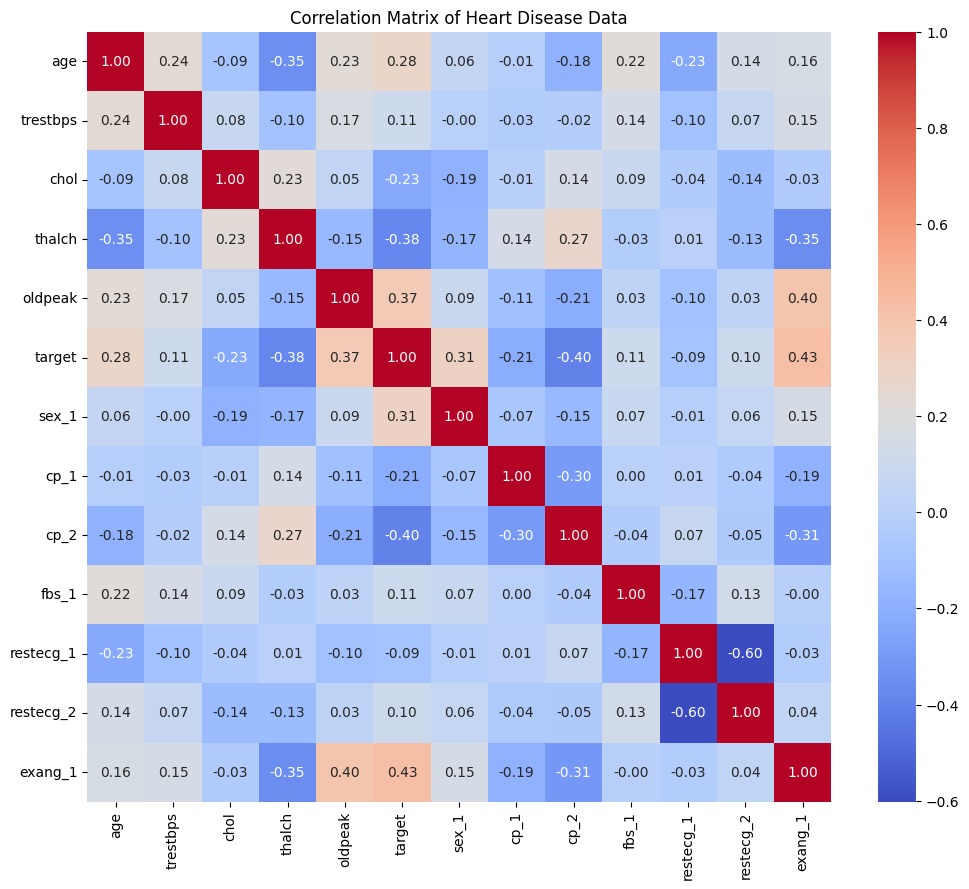

In [11]:
# Correlation Heatmap

df_encoded = pd.get_dummies(df, columns=['sex', 'cp', 'fbs', 'restecg', 'exang'], drop_first=True)
plt.figure(figsize=(12, 10))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix of Heart Disease Data')
plt.show()

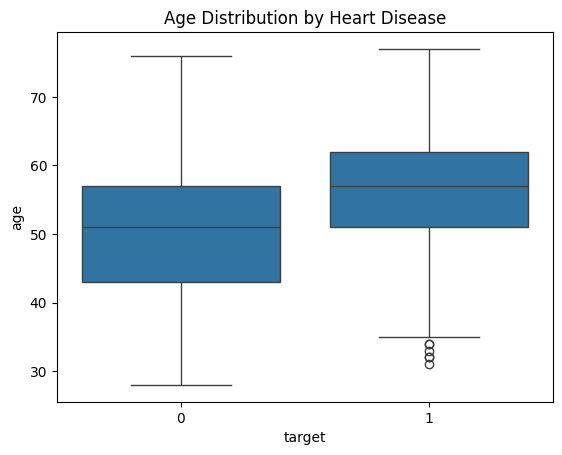

In [12]:
# Age vs Heart Disease

sns.boxplot(x='target', y='age', data=df)
plt.title('Age Distribution by Heart Disease')
plt.show()

In [13]:
# Splitting Features and Target

X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

In [14]:
# Train_Test_Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# Training Model using Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [16]:
# Training Model using Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [17]:
# Checking Accuracy of both models
print('Logistic Regression Accuracy: ', accuracy_score(y_test, y_pred_lr))
print('Decision Tree Accuracy: ', accuracy_score(y_test, y_pred_dt))

Logistic Regression Accuracy:  0.7989130434782609
Decision Tree Accuracy:  0.7228260869565217


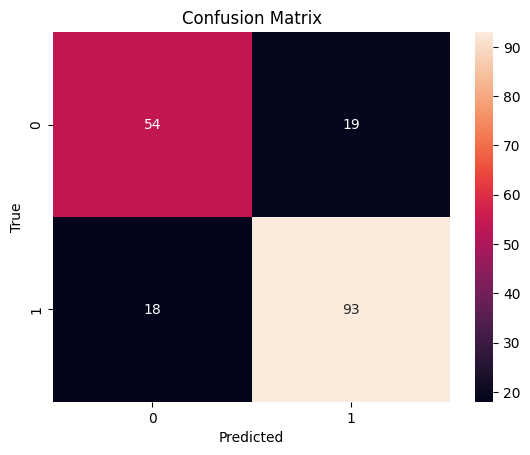

In [18]:
# Confusion Matrics
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

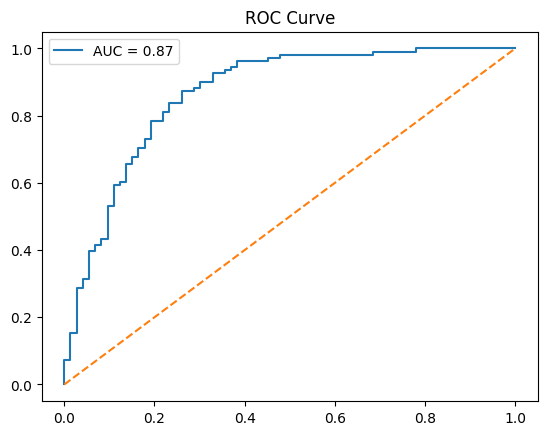

In [19]:
# ROC Curve
y_prob = lr.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')
plt.legend()
plt.title("ROC Curve")
plt.show()

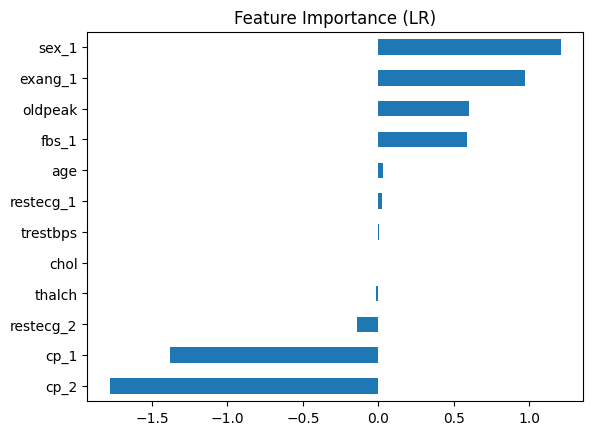

In [20]:
# Feature Importance using Logistic Regression
importance = pd.Series(lr.coef_[0], index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance (LR)")
plt.show()

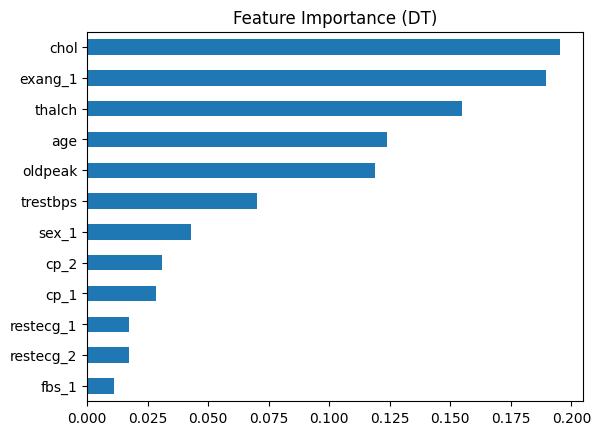

In [21]:
# Feature Importance using Logistic Regression
importance_dt = pd.Series(dt.feature_importances_, index=X.columns)
importance_dt.sort_values().plot(kind='barh')
plt.title("Feature Importance (DT)")
plt.show()